# Distributional diffusion in 2D 🎯

Validates the distributional-diffusion pieces (`EnergyScoreLoss`, `ensemble_apply`, `DistributionalInferenceFn`) on the two-Gaussian mixture from §D.1 of De Bortoli et al., *Distributional Diffusion Models with Scoring Rules* (arXiv:2502.02483):

$$p_0 = \tfrac12 \mathcal N(\mu_1, \sigma^2 I) + \tfrac12 \mathcal N(\mu_2, \sigma^2 I),\quad \mu_1=(3,3),\ \mu_2=(-3,3),\ \sigma=0.5.$$

For this target the posterior $p(x_0 \mid x_t)$ is a closed-form mixture of Gaussians, so we can directly compare what the network learns against the truth. Hyperparameters $\lambda=1,\ \beta=1$ — the classical Gneiting–Raftery energy score (strictly proper).

In [1]:
import functools

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import tqdm

from hackable_diffusion import hd

In [2]:
diffusion_network = hd.diffusion_network
distributional = hd.distributional
time_sampling = hd.time_sampling
gaussian = hd.corruption.gaussian
schedules = hd.corruption.schedules
arch_typing = hd.architecture.arch_typing
conditioning_encoder = hd.architecture.conditioning_encoder
mlp = hd.architecture.mlp
energy_loss = hd.loss.scoring_rules
time_scheduling = hd.sampling.time_scheduling
sampling = hd.sampling.sampling
gaussian_step_sampler = hd.sampling.gaussian_step_sampler
dist_inference = hd.inference.distributional

## Target distribution — paper's two-Gaussian mixture

(np.float64(-5.391115474700928),
 np.float64(5.685082721710205),
 np.float64(1.0517809987068176),
 np.float64(5.081358850002289))

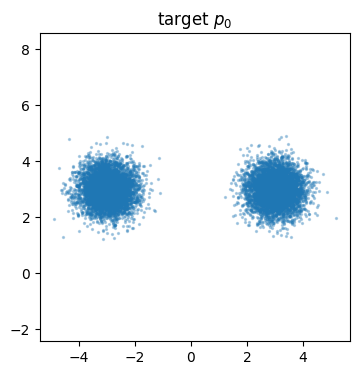

In [3]:
D = 2                         # data dim
MU1 = jnp.array([ 3.0, 3.0])
MU2 = jnp.array([-3.0, 3.0])
SIGMA = 0.5                   # per-component std
N_DATA = 10_240

def sample_data(key, n):
  key_c, key_n = jax.random.split(key)
  comp = jax.random.bernoulli(key_c, shape=(n,))               # 0/1
  mean = jnp.where(comp[:, None], MU1, MU2)                    # [n, 2]
  eps = jax.random.normal(key_n, (n, D))
  return mean + SIGMA * eps

data = sample_data(jax.random.PRNGKey(0), N_DATA)
plt.figure(figsize=(4, 4))
plt.scatter(data[:, 0], data[:, 1], s=2, alpha=0.3)
plt.title('target $p_0$')
plt.axis('equal')

## Noise process — RF (flow-matching) schedule

In [4]:
schedule = schedules.RFSchedule()
process = gaussian.GaussianProcess(schedule=schedule)

## Distributional network

Paper's trick (§D.1): feed the network $[x_t, \xi]$ along the last dim (so input has $2d$ channels), let it output $2d$ channels, then slice the first $d$. The backbone doesn't need any modification — just configure it for $2d$ I/O.

In [5]:
backbone = mlp.ConditionalMLP(
    hidden_sizes_preprocess=(64, 64),
    hidden_sizes_postprocess=(64, 64, 64),
    activation='gelu',
    zero_init_output=False,
    dtype=jnp.float32,
    dropout_rate=0.0,
    conditioning_mechanism=arch_typing.ConditioningMechanism.CONCATENATE,
)
encoder = conditioning_encoder.ConditioningEncoder(
    time_embedder=conditioning_encoder.SinusoidalTimeEmbedder(
        activation='gelu', embedding_dim=128, num_features=128,
    ),
    conditioning_embedders={},
    embedding_merging_method='concat',
    conditioning_rules={'time': arch_typing.ConditioningMechanism.CONCATENATE},
)
# prediction_type='x0' per the paper's distributional setup.
network = diffusion_network.DiffusionNetwork(
    backbone_network=backbone,
    conditioning_encoder=encoder,
    prediction_type='x0',
)

## Training

At each step: draw $M$ independent $\xi\sim\mathcal N(0,I_d)$ per example, run the network with each, stack along an $M$ axis, hand to `EnergyScoreLoss`. `ensemble_apply` wraps this.

In [6]:
M = 16                     # population size (paper uses 32 for 2D; 16 is plenty here)
BATCH = 256
LR = 1e-3
NSTEPS = 8_000             # enough to see the signal; bump for better fits

time_sampler = time_sampling.UniformTimeSampler(safety_epsilon=1e-2)
loss_fn = energy_loss.EnergyScoreLoss(beta=1.0, lam=1.0, prediction_type='x0')
trim_fn = distributional.make_channel_slice(keep_channels=D)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(LR),
)

@jax.jit
def params_loss_fn(params, x0, rng):
  time_rng, corrupt_rng, xi_rng = jax.random.split(rng, 3)
  time = time_sampler(key=time_rng, data_spec=x0)
  xt, targets = process.corrupt(key=corrupt_rng, x0=x0, time=time)
  preds = distributional.ensemble_apply(
      network.apply, {'params': params},
      time=time, xt=xt, conditioning=None,
      xi_rng=xi_rng, population_size=M,
      output_trim=trim_fn,
      is_training=True,
  )
  loss = jnp.mean(loss_fn(preds=preds, targets=targets, time=time))
  return loss, {'loss': loss}

grad_fn = jax.jit(jax.grad(params_loss_fn, has_aux=True))

@jax.jit
def update_fn(params, opt_state, x0, rng):
  grads, metrics = grad_fn(params, x0, rng)
  updates, opt_state = optimizer.update(grads, opt_state)
  params = optax.apply_updates(params, updates)
  return params, opt_state, metrics

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 1/8000 [00:05<13:18:25,  5.99s/it]

  1%|          | 54/8000 [00:06<10:35, 12.51it/s]  

  1%|▏         | 108/8000 [00:06<04:27, 29.48it/s]

  2%|▏         | 162/8000 [00:06<02:30, 51.92it/s]

...

 97%|█████████▋| 7792/8000 [00:20<00:00, 538.16it/s]

 98%|█████████▊| 7846/8000 [00:20<00:00, 538.01it/s]

 99%|█████████▉| 7900/8000 [00:20<00:00, 538.38it/s]

 99%|█████████▉| 7954/8000 [00:20<00:00, 538.23it/s]

100%|██████████| 8000/8000 [00:20<00:00, 387.24it/s]

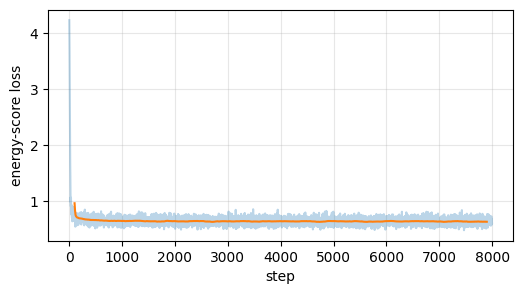

In [7]:
rng = jax.random.PRNGKey(42)
init_rng, rng = jax.random.split(rng)
# Init with 2*D channels — the network sees [x_t, xi] concatenated.
params = network.initialize_variables(
    input_shape=(1, 2 * D),
    conditioning_shape=None,
    key=init_rng,
    is_training=True,
)['params']
opt_state = optimizer.init(params)

losses = []
for step in tqdm.trange(NSTEPS):
  rng, batch_rng, step_rng = jax.random.split(rng, 3)
  idx = jax.random.randint(batch_rng, (BATCH,), 0, N_DATA)
  batch = data[idx]
  params, opt_state, metrics = update_fn(params, opt_state, batch, step_rng)
  losses.append(float(metrics['loss']))

plt.figure(figsize=(6, 3))
plt.plot(losses, alpha=0.3)
ema = np.convolve(losses, np.ones(200) / 200, mode='valid')
plt.plot(np.arange(len(ema)) + 100, ema)
plt.xlabel('step'); plt.ylabel('energy-score loss'); plt.grid(alpha=0.3)

## Diagnostic 1 — learned posterior matches true posterior

For the two-Gaussian mixture, $p(x_0 \mid x_t)$ is a known mixture (see paper Eq. 40):

$$p(x_0|x_t) = w_1 \mathcal N(x_0; \nu_1, \Sigma) + w_2 \mathcal N(x_0; \nu_2, \Sigma),\ \ \Sigma=\tfrac{I}{\alpha_t^2/\sigma_t^2 + 1/\sigma^2},\ \ \nu_k = \Sigma(\tfrac{\alpha_t}{\sigma_t^2} x_t + \tfrac{1}{\sigma^2}\mu_k),$$

with mixing weights $w_k \propto \mathcal N(x_t;\alpha_t\mu_k, (\alpha_t^2\sigma^2+\sigma_t^2)I)$. We compare: for a fixed $x_0^\star$, draw $x_t\sim p_{t|0}(\cdot|x_0^\star)$, then compare many samples from the true posterior with many $\hat x_\theta(t, x_t, \xi_j)$ samples.

In [8]:
def true_posterior_params(xt, alpha_t, sigma_t):
  sig2_post = 1.0 / (alpha_t**2 / sigma_t**2 + 1.0 / SIGMA**2)
  nu = lambda mu: sig2_post * (alpha_t / sigma_t**2 * xt + mu / SIGMA**2)
  # mixing weights from x_t density under each component's predictive
  pred_var = alpha_t**2 * SIGMA**2 + sigma_t**2
  def log_w(mu):
    return -0.5 * jnp.sum((xt - alpha_t * mu)**2) / pred_var
  lw1, lw2 = log_w(MU1), log_w(MU2)
  lw_max = jnp.maximum(lw1, lw2)
  w1 = jnp.exp(lw1 - lw_max); w2 = jnp.exp(lw2 - lw_max)
  w1, w2 = w1 / (w1 + w2), w2 / (w1 + w2)
  return nu(MU1), nu(MU2), sig2_post, w1, w2

def sample_true_posterior(key, xt, alpha_t, sigma_t, n):
  nu1, nu2, sig2_post, w1, _ = true_posterior_params(xt, alpha_t, sigma_t)
  ck, nk = jax.random.split(key)
  comp = jax.random.bernoulli(ck, p=w1, shape=(n,))
  mean = jnp.where(comp[:, None], nu1, nu2)
  return mean + jnp.sqrt(sig2_post) * jax.random.normal(nk, (n, D))

def model_samples(key, xt_single, time_scalar, n):
  xt = jnp.broadcast_to(xt_single[None], (n, D))
  time = jnp.full((n,), time_scalar)
  xi_rng = key
  xi = jax.random.normal(xi_rng, xt.shape, dtype=xt.dtype)
  xt_ext = jnp.concatenate([xt, xi], axis=-1)
  out = network.apply({'params': params}, time=time, xt=xt_ext,
                      conditioning=None, is_training=False)
  return out['x0'][..., :D]

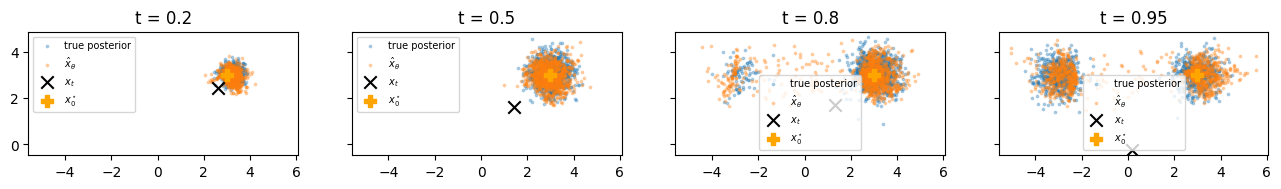

In [9]:
# Pick x0 = mu_1, draw x_t at several times, compare posteriors.
times_to_show = [0.2, 0.5, 0.8, 0.95]
fig, axes = plt.subplots(1, len(times_to_show), figsize=(4 * len(times_to_show), 4),
                         sharex=True, sharey=True)
rng_vis = jax.random.PRNGKey(7)
for ax, t in zip(axes, times_to_show):
  k_xt, k_true, k_model, rng_vis = jax.random.split(rng_vis, 4)
  time_arr = jnp.array([t])
  xt_samples, _ = process.corrupt(key=k_xt, x0=MU1[None], time=time_arr)
  xt = xt_samples[0]
  alpha_t = float(schedule.alpha(time_arr)[0])
  sigma_t = float(schedule.sigma(time_arr)[0])
  true_pts = sample_true_posterior(k_true, xt, alpha_t, sigma_t, 1000)
  pred_pts = model_samples(k_model, xt, t, 1000)
  ax.scatter(true_pts[:, 0], true_pts[:, 1], s=3, alpha=0.3, label='true posterior')
  ax.scatter(pred_pts[:, 0], pred_pts[:, 1], s=3, alpha=0.3, label='$\\hat x_\\theta$')
  ax.scatter([xt[0]], [xt[1]], marker='x', c='k', s=80, label='$x_t$')
  ax.scatter([MU1[0]], [MU1[1]], marker='P', c='orange', s=80, label='$x_0^\\star$')
  ax.set_title(f't = {t}')
  ax.legend(fontsize=7, loc='best'); ax.set_aspect('equal')

## Diagnostic 2 — posterior standard deviation vs $t$

Fig. 5 (right) of the paper. The learned $\hat x_\theta(t,x_t,\xi)$ should have (approximately) the same dispersion as the true posterior as we sweep $t$. This is the whole point of learning a scoring rule rather than a regression loss: the mean is *identifiable* from MSE, but the spread is not — and without it you can't take big reverse steps.

Text(0.5, 1.0, 'learned vs true posterior dispersion')

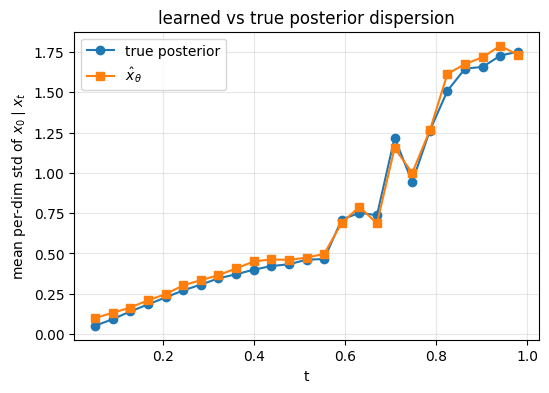

In [10]:
ts = jnp.linspace(0.05, 0.98, 25)
rng_diag = jax.random.PRNGKey(11)

true_stds, pred_stds = [], []
for t in ts:
  k_x0, k_xt, k_true, k_model, rng_diag = jax.random.split(rng_diag, 5)
  # Average over 8 anchor x_t points for a smoother curve.
  x0 = sample_data(k_x0, 8)
  time_arr = jnp.full((8,), float(t))
  xt_batch, _ = process.corrupt(key=k_xt, x0=x0, time=time_arr)
  alpha_t = float(schedule.alpha(time_arr)[0])
  sigma_t = float(schedule.sigma(time_arr)[0])
  # For each x_t, draw 256 samples from both posteriors and compute std.
  def per_xt(xt_i, k_t, k_m):
    tp = sample_true_posterior(k_t, xt_i, alpha_t, sigma_t, 256)
    mp = model_samples(k_m, xt_i, float(t), 256)
    return tp.std(axis=0).mean(), mp.std(axis=0).mean()
  k_ts = jax.random.split(k_true, 8)
  k_ms = jax.random.split(k_model, 8)
  pairs = [per_xt(xt_batch[i], k_ts[i], k_ms[i]) for i in range(8)]
  true_stds.append(np.mean([float(a) for a, _ in pairs]))
  pred_stds.append(np.mean([float(b) for _, b in pairs]))

plt.figure(figsize=(6, 4))
plt.plot(ts, true_stds, 'o-', label='true posterior')
plt.plot(ts, pred_stds, 's-', label='$\\hat x_\\theta$')
plt.xlabel('t'); plt.ylabel('mean per-dim std of $x_0 \\mid x_t$')
plt.legend(); plt.grid(alpha=0.3)
plt.title('learned vs true posterior dispersion')

## Few-step sampling via `DistributionalInferenceFn`

The payoff: a distributional model should give reasonable samples at very few reverse steps (5–10), whereas a regression-MSE model collapses to the conditional mean and needs many steps.

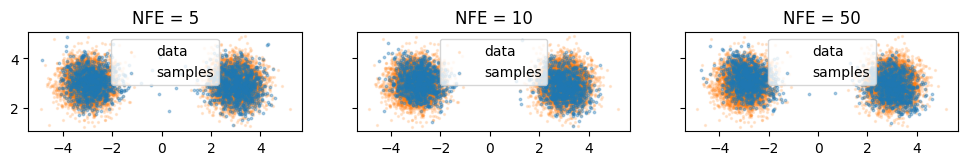

In [11]:
def sample_distributional(key, num_steps, n_samples=2048):
  inf_fn = dist_inference.DistributionalInferenceFn(
      network=network, params=params, keep_channels=D,
  )
  time_schedule = time_scheduling.UniformTimeSchedule(safety_epsilon=1e-3)
  stepper = gaussian_step_sampler.DDIMStep(
      corruption_process=process, stoch_coeff=0.0,
  )
  sampler = sampling.DiffusionSampler(
      time_schedule=time_schedule, stepper=stepper,
      num_steps=num_steps, return_trajectory=False,
  )
  init = jax.random.normal(key, (n_samples, D))
  last, _ = sampler(inference_fn=inf_fn, rng=key,
                    initial_noise=init, conditioning=None)
  return last.xt

nfes = [5, 10, 50]
fig, axes = plt.subplots(1, len(nfes), figsize=(4 * len(nfes), 4),
                         sharex=True, sharey=True)
for ax, n in zip(axes, nfes):
  samples = sample_distributional(jax.random.PRNGKey(100 + n), n)
  ax.scatter(data[:, 0], data[:, 1], s=2, alpha=0.15, label='data', c='C1')
  ax.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.35, label='samples', c='C0')
  ax.set_title(f'NFE = {n}'); ax.legend(); ax.set_aspect('equal')